Kristal Lee \
DSC 540\
Prof. Catherine Williams\
Summer 2024\
4 Aug 2024\

# Project Milestone 5

In [501]:
# load necessary libraries
import sqlite3
import pandas as pd
import numpy as np

In [502]:
# load data sets from previous milestones
df1 = pd.read_csv('data1.csv')
df2 = pd.read_csv('data2.csv')
df3 = pd.read_csv('data3.csv')

In [503]:
# connect so sqlite database
conn = sqlite3.connect('term-project-540.db')

In [504]:
# load tables from previous milestones into database
df1.to_sql('most_stream_2023', conn, if_exists='replace')
df2.to_sql('billboard', conn, if_exists='replace')
df3.to_sql('playlists', conn, if_exists='replace')

130

In [505]:
# query for a joined onto the spotify most streamed 2023 data
# join based on song title
# save as a dataframe
merged_all_df = pd.read_sql("SELECT most_stream_2023.*, billboard.rank,playlists.popularity \
FROM (most_stream_2023 INNER JOIN billboard \
ON most_stream_2023.song_name = billboard.Title) \
INNER JOIN playlists ON most_stream_2023.song_name = playlists.track_title", conn)

In [506]:
# songs that overlapped in all three tables
merged_all_df = merged_all_df.drop(['index','Unnamed: 0'], axis=1)

In [507]:
merged_all_df['song_name'] = merged_all_df['song_name'].apply(lambda x:x.title())
merged_all_df['main_artist'] = merged_all_df['main_artist'].apply(lambda x:x.title())

In [508]:
# add joined table to sql database
merged_all_df.to_sql('merged_all', conn, if_exists='replace')

2

In [509]:
# query for joined table from most streams and billboard 100
# joined based on song titles
# save as a dataframe
spot_bill_df = pd.read_sql("SELECT most_stream_2023.song_name, most_stream_2023.main_artist,\
most_stream_2023.bpm, most_stream_2023.mode, billboard.rank \
FROM most_stream_2023 INNER JOIN billboard \
ON most_stream_2023.song_name = billboard.Title", conn)

In [510]:
# display first few rows
spot_bill_df.head(2)

,song_name,main_artist,bpm,mode,Rank
0,as it was,harry styles,174,Minor,2
1,i ain't worried,onerepublic,140,Major,37


In [511]:
# query for joined table from popular playlists and most streamed songs in 2023
# joined based on artist
# save as a dataframe
spot_pl_df = pd.read_sql("SELECT playlists.artists, playlists.track_title, \
most_stream_2023.song_name \
FROM playlists INNER JOIN most_stream_2023 \
ON playlists.artists = most_stream_2023.main_artist", conn)

In [512]:
# display first few rows
spot_pl_df.head(2)

,artists,track_title,song_name
0,billie eilish,birds of a feather,bored
1,billie eilish,birds of a feather,happier than ever


In [513]:
# import library for visualizations
import matplotlib.pyplot as plt

In [514]:
# get counts for artists in the combined dataframe
artists = spot_pl_df['artists'].value_counts().keys().tolist()
counts = spot_pl_df['artists'].value_counts().tolist()

In [515]:
# get the top ten artists from the dataset and their song counts
artists = artists[:9]
counts = counts[:9]

In [516]:
# put artist names in title case
prop_art = []
for i in range(len(artists)):
    prop_art.append(artists[i].title())

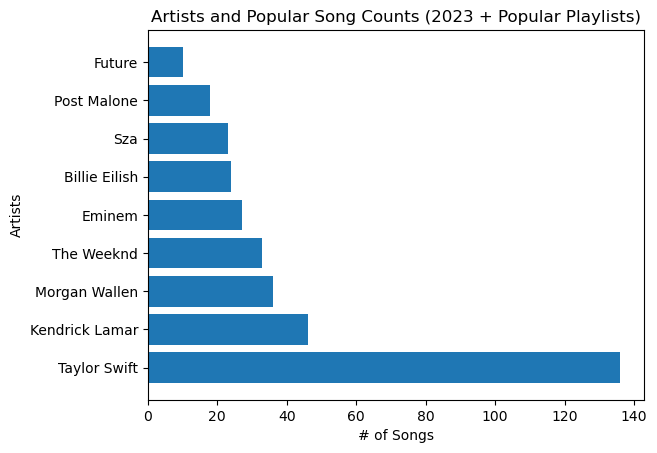

In [517]:
# plot chart of number of songs for top ten artits between the two tables
plt.barh(prop_art, counts)
plt.ylabel('Artists')
plt.xlabel('# of Songs')
plt.title('Artists and Popular Song Counts (2023 + Popular Playlists)')
plt.show()

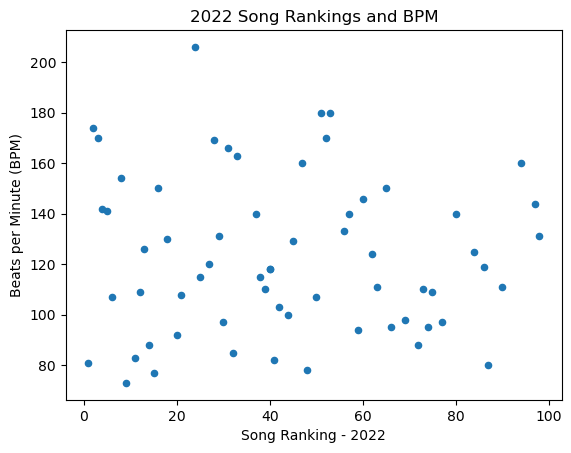

In [518]:
# plot of ranked songs from 2022 and their beats per minute
spot_bill_df.plot.scatter('Rank', 'bpm')
plt.ylabel('Beats per Minute (BPM)')
plt.xlabel('Song Ranking - 2022')
plt.title('2022 Song Rankings and BPM')
plt.show()

In [519]:
# convert to int otherwise return null value
def toint(x):
    try: 
        int(x)
        return int(x)
    except:
        return np.nan

In [520]:
# apply int function
df1['streams'] = df1['streams'].apply(toint)

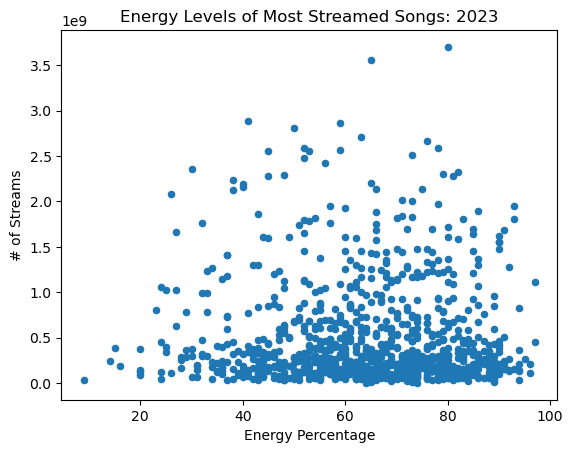

In [521]:
# plot energy levels by number of streams for most streamed songs
df1.plot.scatter('energy_%','streams')
plt.xlabel('Energy Percentage')
plt.ylabel('# of Streams')
plt.title('Energy Levels of Most Streamed Songs: 2023')
plt.show()

In [522]:
# list of top 25 artists by count of songs in most streamed dataset
top25 = list(df1['main_artist'].value_counts().keys()[:25])


In [523]:
# create new dataframe with just the top 25 artists
df1_top = df1[df1['main_artist'].isin(top25)]
df1_top = df1_top[['main_artist','mode']]

In [524]:
# count of major and minor modes amongst the songs
major = df1_top[df1_top['mode']=='Major'].value_counts()
minor = df1_top[df1_top['mode']=='Minor'].value_counts()

In [525]:
# all the counts of songs by artist
main_all = pd.DataFrame(df1_top['main_artist'].value_counts())

In [526]:
# merge counts based on who the main artist is
counts2 = pd.merge(main_all, major, on='main_artist')
counts2 = pd.merge(counts2, minor, on='main_artist')
counts2 = counts2.drop('count_x', axis=1)
counts2.head(2)

,count_y,count
main_artist,,
taylor swift,30,4
the weeknd,15,18


In [527]:
prop_art2 = []
for i in range(len(counts2)):
    prop_art2.append(counts2.index[i].title())

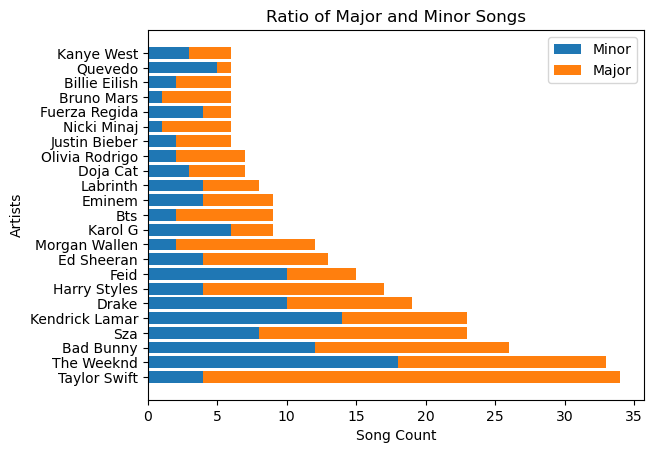

In [528]:
# plot stacked bar chart with ratio of each artists songs as minor to major keys
fig, ax = plt.subplots()
ax.barh(prop_art2, counts2['count'], label='Minor')
ax.barh(prop_art2, counts2['count_y'], left=counts2['count'], label='Major')
ax.legend()
plt.ylabel('Artists')
plt.xlabel('Song Count')
plt.title('Ratio of Major and Minor Songs')
plt.show()

In [529]:
# dataframe of the top artist in the top streamed for 2023 (Taylor Swift)
tswift = df1[df1['main_artist']=='taylor swift']
# re-index the subset
tswift.index = pd.RangeIndex(len(tswift.index))

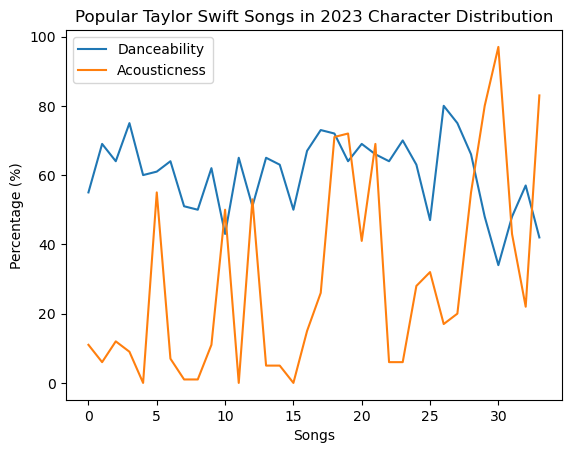

In [530]:
# plot songs for danceability and acousticness
plt.plot(tswift.index, tswift['danceability_%'], label = 'Danceability')
plt.plot(tswift.index, tswift['acousticness_%'], label = 'Acousticness')
plt.legend()
plt.ylabel('Percentage (%)')
plt.xlabel('Songs')
plt.title('Popular Taylor Swift Songs in 2023 Character Distribution')
plt.show()

In [531]:
# result of joining all tables
merged_all_df

,song_name,main_artist,artist_count,released_year,released_month,released_day,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,Rank,popularity
0,Something In The Orange,Zach Bryan,1,2022,4,22,449701773,110,Major,59,22,38,42,0,12,3,39,87
1,Better Days,Neiked,3,2021,9,24,421040617,110,Minor,72,67,68,0,0,14,4,73,79


# Summary

Overall, the main changes that were made to the data were transformations that made the different datasets were ones to make the tables comparable along song titles and artists. This involved string cleaning with removing any featured artists in song titles, removing additional artists other than the first listed artist, and putting all the strings in the same type-case. The assumption that was made was that the first artist listed when there were multiple artists on a song was the first artists is the primary. The implication and potential risk by doing such transformations are that other artists that are a part of the songs are not properly represented in this data. Ways this could have been mitigated is by looking further into how multiple artists were represented in the songs and listed them out differently or separately. The data use was either gathered from Spotify or as in the case of the Billboard Top 100 songs from 2022, their original source was from the Billboard website itself. One element that could run an ethical risk is in how these top song lists are determined, primarily for the Billboard and Spotify created playlists. There could be some bias in the criteria that awards them a spot on these lists. Compared to the most streamed list from 2023 where there is an objective metric of number of streams which determines its place on the list. 
